
# Factor Momentum on Equity Risk-Factor ETFs
## A gross implementation of Arnott et al. (2020) with stationary-bootstrap robustness

This notebook implements and evaluates a **gross cross-sectional Factor Momentum strategy** on equity risk-factor ETFs, following the intuition of **Arnott et al. (2020)**.

### What is included
- signal construction for **6–1** and **12–1** cross-sectional factor momentum;
- a **monthly rebalancing backtest implemented correctly** (weights are entered on the next trading day after signal observation and then allowed to drift until the next rebalance);
- performance and risk-adjusted performance metrics;
- **Politis–Romano stationary bootstrap** to obtain empirical distributions of key metrics.

### What is intentionally left for future extensions
- realistic transaction costs and the move from **gross** to **net** performance;
- a **risk-managed momentum** overlay *à la* **Barroso and Santa-Clara (2015)** to test whether volatility-managed momentum also improves **factor momentum** rather than only standard momentum;
- any broader universe expansion, alternative factor definitions, or more advanced portfolio overlays.

### Current reported results from the latest run
For the best specification (**MomTop1_80_20**), the latest reported results are:
- **CAGR:** 14.0%
- **Annualized volatility:** 17.5%
- **Sharpe ratio:** 0.84
- **Martin ratio:** 2.45
- **Maximum drawdown:** -33.2%
- **Politis–Romano stationary bootstrap:** median CAGR 12.5% with 5th–95th percentile range 4.4%–20.2%.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except Exception:
    yf = None


# ============================================================
# DATA
# ============================================================

TICKERS = {
    "Value": "RPV",
    "Size": "SIZE",
    "Momentum": "MTUM",
    "Quality": "SPHQ",
    "LowVol": "SPLV",
}

FACTOR_NAMES = ["Value", "Size", "Momentum", "Quality", "LowVol"]


def load_factor_etf_returns_hdf(filepath: str, key: str = "/FactorETFs") -> pd.DataFrame:
    """
    Load daily factor-ETF returns from your HDF store.
    Expected shape: 5 columns corresponding to Value / Size / Momentum / Quality / LowVol.
    """
    r = pd.read_hdf(filepath, key)
    r.index = pd.to_datetime(r.index)
    r.index.name = "Date"

    # start where all ETFs are jointly available
    start = r.dropna().index[0]
    r = r.loc[start:].copy()

    if r.shape[1] == 5:
        r.columns = FACTOR_NAMES
    return r.astype(float)


def download_factor_etf_returns(start: str = "2000-01-01") -> pd.DataFrame:
    """
    Convenience loader via Yahoo Finance.
    """
    if yf is None:
        raise ImportError("yfinance is not available in this environment.")

    px = yf.download(
        list(TICKERS.values()),
        start=start,
        auto_adjust=True,
        progress=False,
    )["Close"]

    px = px.rename(columns={v: k for k, v in TICKERS.items()})
    r = px.pct_change().dropna(how="all")
    r.index = pd.to_datetime(r.index)
    r.index.name = "Date"
    return r.astype(float)


In [2]:

# ============================================================
# SIGNAL + WEIGHTS
# ============================================================

def month_end_trading_dates(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """
    Last actual trading day of each month.
    """
    s = pd.Series(idx, index=idx)
    eom = s.groupby(s.index.to_period("M")).max()
    return pd.DatetimeIndex(eom.values)


def get_variant_params(variant: str) -> tuple[int, int]:
    """
    6-1  -> 6 months formation, 1 month skip
    12-1 -> 12 months formation, 1 month skip
    """
    tdpm = 21
    if variant == "6-1":
        return 6 * tdpm, 1 * tdpm
    elif variant == "12-1":
        return 12 * tdpm, 1 * tdpm
    raise ValueError("variant must be '6-1' or '12-1'")


def cs_mom_signal_monthly(
    r: pd.DataFrame,
    formation_days: int,
    skip_days: int,
) -> pd.DataFrame:
    """
    Cross-sectional momentum signal:
    signal_t = cumulative log-return over [t-skip-formation+1, ..., t-skip]
    computed daily, then sampled at month-end trading dates.
    """
    sig_daily = np.log1p(r).shift(skip_days).rolling(
        formation_days,
        min_periods=formation_days,
    ).sum()

    eom_dates = month_end_trading_dates(r.index)
    sig_m = sig_daily.loc[eom_dates].dropna(how="all")
    sig_m.index.name = "Date"
    return sig_m


def w_top1_80_20(sig_m: pd.DataFrame) -> pd.DataFrame:
    n = sig_m.shape[1]
    rest = 0.2 / (n - 1)
    w = pd.DataFrame(rest, index=sig_m.index, columns=sig_m.columns, dtype=float)
    top = sig_m.idxmax(axis=1)
    for dt, a in top.items():
        w.loc[dt, a] = 0.8
    return w


def w_top2_35_35(sig_m: pd.DataFrame) -> pd.DataFrame:
    n = sig_m.shape[1]
    rest = 0.3 / (n - 2)
    w = pd.DataFrame(rest, index=sig_m.index, columns=sig_m.columns, dtype=float)
    for dt in sig_m.index:
        top2 = sig_m.loc[dt].nlargest(2).index
        w.loc[dt, top2] = 0.35
    return w


def w_equal(sig_m: pd.DataFrame) -> pd.DataFrame:
    n = sig_m.shape[1]
    return pd.DataFrame(1.0 / n, index=sig_m.index, columns=sig_m.columns, dtype=float)


In [3]:

# ============================================================
# BACKTEST
# ============================================================

def _entry_dates_from_signal_dates(
    trading_idx: pd.DatetimeIndex,
    signal_dates: pd.DatetimeIndex,
) -> tuple[pd.DatetimeIndex, pd.DatetimeIndex]:
    """
    Map each signal date (month-end close) to the next trading day,
    because weights can only be implemented after observing the signal.
    """
    entries = []
    keep = []
    for dt in signal_dates:
        pos = trading_idx.searchsorted(dt, side="right")
        if pos < len(trading_idx):
            entries.append(trading_idx[pos])
            keep.append(dt)
    return pd.DatetimeIndex(entries), pd.DatetimeIndex(keep)


def backtest_monthly_rebalance_with_drift(
    r: pd.DataFrame,
    w_m: pd.DataFrame,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """
    Correct monthly rebalance backtest.

    Important:
    - the signal is observed at month-end,
    - target weights are implemented on the NEXT trading day,
    - within the month, weights DRIFT with asset returns,
      i.e. there is no hidden daily rebalancing.

    Returns
    -------
    port_ret : daily portfolio return series
    w_d      : daily start-of-day portfolio weights actually held
    w_sched  : target weights at each implementation date
    """
    r = r.dropna(how="any").copy()

    entries, keep = _entry_dates_from_signal_dates(r.index, w_m.index)
    if len(entries) == 0:
        return (
            pd.Series(dtype=float, name="portfolio"),
            pd.DataFrame(columns=r.columns, dtype=float),
            pd.DataFrame(columns=r.columns, dtype=float),
        )

    w_sched = w_m.loc[keep].copy()
    w_sched.index = entries
    w_sched = w_sched[~w_sched.index.duplicated(keep="first")]
    entries = w_sched.index

    port = pd.Series(index=r.index, dtype=float, name="portfolio")
    w_d = pd.DataFrame(index=r.index, columns=r.columns, dtype=float)

    entry_pos = [r.index.get_loc(dt) for dt in entries]

    for i, start_pos in enumerate(entry_pos):
        end_pos = entry_pos[i + 1] - 1 if i + 1 < len(entry_pos) else len(r.index) - 1
        current_w = w_sched.iloc[i].astype(float).values
        current_w = current_w / current_w.sum()

        for pos in range(start_pos, end_pos + 1):
            dt = r.index[pos]
            x = r.iloc[pos].astype(float).values

            # weights held at the START of day t
            w_d.loc[dt] = current_w

            # portfolio return for day t
            rp = float(np.dot(current_w, x))
            port.loc[dt] = rp

            # end-of-day drift into next day
            current_w = current_w * (1.0 + x) / (1.0 + rp)

    mask = port.notna()
    return port.loc[mask], w_d.loc[mask], w_sched


def run_factor_mom_from_returns(
    r: pd.DataFrame,
    variant: str = "6-1",
) -> dict:
    formation_days, skip_days = get_variant_params(variant)
    sig_m = cs_mom_signal_monthly(
        r,
        formation_days=formation_days,
        skip_days=skip_days,
    )

    weight_schemes = {
        "MomTop1_80_20": w_top1_80_20(sig_m),
        "MomTop2_35_35": w_top2_35_35(sig_m),
        "EW": w_equal(sig_m),
    }

    rets = {}
    daily_weights = {}
    entry_weights = {}

    for name, w_m in weight_schemes.items():
        p, w_d, w_sched = backtest_monthly_rebalance_with_drift(r, w_m)
        rets[name] = p.rename(name)
        daily_weights[name] = w_d
        entry_weights[name] = w_sched

    rets = pd.concat(rets.values(), axis=1)
    avg_daily_weights = pd.concat({k: v.mean() for k, v in daily_weights.items()}, axis=1)
    avg_entry_weights = pd.concat({k: v.mean() for k, v in entry_weights.items()}, axis=1)

    return {
        "rets": rets,
        "signal": sig_m,
        "daily_weights": daily_weights,
        "entry_weights": entry_weights,
        "avg_daily_weights": avg_daily_weights,
        "avg_entry_weights": avg_entry_weights,
    }


In [4]:

# ============================================================
# PERFORMANCE METRICS
# ============================================================

def max_drawdown_from_wealth(wealth: pd.Series) -> float:
    wealth = wealth.dropna().astype(float)
    if len(wealth) == 0:
        return np.nan
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    return float(dd.min())


def ulcer_index(r: pd.Series) -> float:
    r = r.dropna().astype(float)
    if len(r) == 0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    return float(np.sqrt(np.mean(dd**2)))


def cagr(r: pd.Series, ann: int = 252) -> float:
    r = r.dropna().astype(float)
    if len(r) == 0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    years = len(r) / ann
    return float(wealth.iloc[-1] ** (1 / years) - 1) if years > 0 else np.nan


def perf_metrics(r: pd.Series, rf_daily: float = 0.0, ann: int = 252) -> dict:
    r = r.dropna().astype(float)
    if len(r) < 5:
        return {"n": int(len(r))}

    ex = r - rf_daily

    mu_d = ex.mean()
    vol_d = ex.std(ddof=1)
    shr = (mu_d / vol_d) * np.sqrt(ann) if vol_d > 0 else np.nan

    downside = ex.copy()
    downside[downside > 0] = 0.0
    dvol = downside.std(ddof=1)
    sor = (mu_d / dvol) * np.sqrt(ann) if dvol > 0 else np.nan

    cagr_ = cagr(r, ann=ann)
    ann_vol = r.std(ddof=1) * np.sqrt(ann)

    wealth = (1.0 + r).cumprod()
    mxdd = max_drawdown_from_wealth(wealth)
    calmar = (cagr_ / abs(mxdd)) if (mxdd < 0 and np.isfinite(mxdd)) else np.nan

    ui = ulcer_index(r)
    rf_ann = (1.0 + rf_daily) ** ann - 1.0
    martin = ((cagr_ - rf_ann) / ui) if (ui > 0 and np.isfinite(ui)) else np.nan

    return {
        "n": int(len(r)),
        "CAGR": float(cagr_),
        "AnnVol": float(ann_vol),
        "MxDD": float(mxdd),
        "ShR": float(shr),
        "SoR": float(sor),
        "Calmar": float(calmar),
        "Ulcer": float(ui),
        "Martin": float(martin),
    }


def perf_table(F: pd.DataFrame, rf_daily: float = 0.0, ann: int = 252) -> pd.DataFrame:
    return pd.DataFrame(
        {c: perf_metrics(F[c], rf_daily=rf_daily, ann=ann) for c in F.columns}
    ).T


def wealth_index(F: pd.DataFrame) -> pd.DataFrame:
    return (1.0 + F).cumprod()


In [5]:

# ============================================================
# POLITIS-ROMANO STATIONARY BOOTSTRAP
# ============================================================

def stationary_bootstrap_indices(
    T: int,
    avg_block_len: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Politis-Romano stationary bootstrap:
    block lengths are geometric with mean avg_block_len.
    """
    p = 1.0 / avg_block_len
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(0, T)

    for t in range(1, T):
        if rng.random() < p:
            idx[t] = rng.integers(0, T)
        else:
            idx[t] = (idx[t - 1] + 1) % T
    return idx


def stationary_bootstrap_df(
    df: pd.DataFrame,
    n_boot: int = 1000,
    avg_block_len: float = 10.0,
    seed: int = 1,
):
    """
    Bootstrap the RAW factor-ETF return panel.
    The bootstrapped returns are then re-mapped to the original trading calendar
    so that month-end signal extraction still works naturally.
    """
    rng = np.random.default_rng(seed)
    T = len(df)

    for _ in range(n_boot):
        ii = stationary_bootstrap_indices(T, avg_block_len, rng)
        boot = df.iloc[ii].copy()
        boot.index = df.index
        yield boot


def summarize_vec(x: np.ndarray) -> pd.Series:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return pd.Series(
            {"mean": np.nan, "p05": np.nan, "p50": np.nan, "p95": np.nan, "n": 0}
        )

    return pd.Series({
        "mean": float(np.mean(x)),
        "p05": float(np.quantile(x, 0.05)),
        "p50": float(np.quantile(x, 0.50)),
        "p95": float(np.quantile(x, 0.95)),
        "n": int(len(x)),
    })


def bootstrap_factor_mom_metrics(
    r: pd.DataFrame,
    variant: str = "6-1",
    metrics=("CAGR", "AnnVol", "ShR", "SoR", "Calmar", "Martin", "MxDD"),
    n_boot: int = 1000,
    avg_block_len: float = 10.0,
    seed: int = 1,
    rf_daily: float = 0.0,
    ann: int = 252,
) -> dict:
    """
    Bootstrap the RAW factor-ETF returns and, inside each bootstrap replica,
    re-run the ENTIRE strategy construction:
    signal -> weights -> backtest -> metrics.
    """
    actual = run_factor_mom_from_returns(r, variant=variant)["rets"]
    strategies = list(actual.columns)
    actual_metrics = perf_table(actual, rf_daily=rf_daily, ann=ann)

    mats = {(m, s): np.full(n_boot, np.nan) for m in metrics for s in strategies}

    for i, sim in enumerate(
        stationary_bootstrap_df(
            r,
            n_boot=n_boot,
            avg_block_len=avg_block_len,
            seed=seed,
        )
    ):
        sim_rets = run_factor_mom_from_returns(sim, variant=variant)["rets"]
        tab = perf_table(sim_rets, rf_daily=rf_daily, ann=ann)

        for s in strategies:
            for m in metrics:
                mats[(m, s)][i] = tab.loc[s, m]

    out_tables = {}
    for m in metrics:
        rows = []
        for s in strategies:
            sm = summarize_vec(mats[(m, s)])
            sm["Strategy"] = s
            rows.append(sm)
        out_tables[m] = pd.DataFrame(rows).set_index("Strategy")

    return {
        "actual_metrics": actual_metrics,
        "bootstrap_tables": out_tables,
        "simulated_metric_vectors": mats,
    }


In [6]:

# ============================================================
# OPTIONAL: SIMPLE DATA-DRIVEN BLOCK-LENGTH CHOICE
# ============================================================

def _acf(x: np.ndarray, nlags: int) -> np.ndarray:
    x = np.asarray(x, float)
    x = x - np.mean(x)

    denom = np.dot(x, x)
    if denom <= 0:
        return np.zeros(nlags + 1)

    out = np.empty(nlags + 1, float)
    out[0] = 1.0
    for k in range(1, nlags + 1):
        out[k] = np.dot(x[:-k], x[k:]) / denom
    return out


def choose_block_length_by_acf_matching(
    s: pd.Series,
    candidates=(5, 10, 20, 30),
    nlags: int = 20,
    n_boot: int = 300,
    use_abs: bool = True,
    seed: int = 1,
    distance: str = "weighted",
) -> dict:
    """
    Pick block length by matching the ACF of the strategy (or abs(strategy)),
    which is useful when you want the bootstrap to preserve volatility clustering.
    """
    r = s.dropna().astype(float)
    x = np.abs(r.values) if use_abs else r.values
    target = _acf(x, nlags)

    rng = np.random.default_rng(seed)
    scores = {}
    boot_means = {}

    for L in candidates:
        acfs = np.zeros((n_boot, nlags + 1))

        for b in range(n_boot):
            ii = stationary_bootstrap_indices(len(x), float(L), rng)
            xb = x[ii]
            acfs[b] = _acf(xb, nlags)

        m = acfs.mean(axis=0)
        boot_means[L] = m
        diff = m[1:] - target[1:]  # ignore lag 0

        if distance == "l1":
            score = float(np.mean(np.abs(diff)))
        elif distance == "l2":
            score = float(np.sqrt(np.mean(diff**2)))
        elif distance == "weighted":
            w = 1.0 / np.arange(1, nlags + 1)
            score = float(np.sqrt(np.mean(diff**2 * w)))
        else:
            raise ValueError("distance must be 'l1', 'l2', or 'weighted'")

        scores[L] = score

    scores = pd.Series(scores).sort_index()

    return {
        "best_L": int(scores.idxmin()),
        "scores": scores,
        "target_acf": target,
        "boot_acf_mean": boot_means,
    }



## Configuration

Choose the data source and the main backtest options below.

- Use **`DATA_SOURCE = "hdf"`** to replicate the original master-project dataset.
- Use **`DATA_SOURCE = "yahoo"`** for a lightweight public-data version that is easier to share on GitHub.


In [13]:

# ============================================================
# USER CONFIGURATION
# ============================================================

DATA_SOURCE = "yahoo"          # "yahoo" or "hdf"
HDF_PATH = None                 # e.g. "data/factor_etfs.h5" if DATA_SOURCE == "hdf"
HDF_KEY = "/FactorETFs"
START_DATE = "2000-01-01"
VARIANT = "6-1"                # "6-1" or "12-1"

RUN_ACF_BLOCK_SELECTION = True
ACF_CANDIDATES = (5, 10, 20, 30)
ACF_NLAGS = 20
ACF_N_BOOT = 300

RUN_BOOTSTRAP = True
N_BOOT = 1000
AVG_BLOCK_LEN = 10             # used when RUN_ACF_BLOCK_SELECTION = False
BOOTSTRAP_SEED = 7


## Load data and run the factor-momentum backtest

In [14]:

# ============================================================
# LOAD DATA
# ============================================================

if DATA_SOURCE == "hdf":
    if HDF_PATH is None:
        raise ValueError("Set HDF_PATH before using DATA_SOURCE='hdf'.")
    r = load_factor_etf_returns_hdf(HDF_PATH, key=HDF_KEY)
elif DATA_SOURCE == "yahoo":
    r = download_factor_etf_returns(start=START_DATE)
else:
    raise ValueError("DATA_SOURCE must be either 'hdf' or 'yahoo'.")

print(f"Loaded returns panel with shape {r.shape} from {r.index.min().date()} to {r.index.max().date()}.")
display(r.head())

# ============================================================
# RUN STRATEGY
# ============================================================

out = run_factor_mom_from_returns(r, variant=VARIANT)
rets = out["rets"]
signal = out["signal"]
avg_daily_w = out["avg_daily_weights"]
avg_entry_w = out["avg_entry_weights"]

actual_metrics = perf_table(rets)
display(actual_metrics.round(4))

print("Average daily weights:")
display(avg_daily_w.round(4))

print("Average entry weights:")
display(avg_entry_w.round(4))


Loaded returns panel with shape (5098, 5) from 2005-12-07 to 2026-03-16.


Ticker,Momentum,Value,Size,Quality,LowVol
Date,,,,,
2005-12-07,NaN,NaN,NaN,-0.010256,NaN
2005-12-08,NaN,NaN,NaN,0.005181,NaN
2005-12-09,NaN,NaN,NaN,0.003222,NaN
2005-12-12,NaN,NaN,NaN,0.006422,NaN
2005-12-13,NaN,NaN,NaN,0.003829,NaN


,n,CAGR,AnnVol,MxDD,ShR,SoR,Calmar,Ulcer,Martin
MomTop1_80_20,3246.0,0.1403,0.1747,-0.3318,0.8392,1.3249,0.4228,0.0573,2.4478
MomTop2_35_35,3246.0,0.1226,0.1629,-0.3681,0.7920,1.2232,0.3332,0.0617,1.9888
EW,3246.0,0.1221,0.1624,-0.3808,0.7908,1.2132,0.3206,0.0612,1.9957


Average daily weights:


,MomTop1_80_20,MomTop2_35_35,EW
Ticker,,,
Momentum,0.3414,0.2369,0.2001
Value,0.2566,0.2042,0.2000
Size,0.0592,0.1729,0.1999
Quality,0.1728,0.2042,0.2003
LowVol,0.1700,0.1818,0.1997


Average entry weights:


,MomTop1_80_20,MomTop2_35_35,EW
Ticker,,,
Momentum,0.3385,0.2378,0.2
Value,0.2567,0.2042,0.2
Size,0.0596,0.1721,0.2
Quality,0.1750,0.2042,0.2
LowVol,0.1702,0.1817,0.2


## Plot cumulative wealth

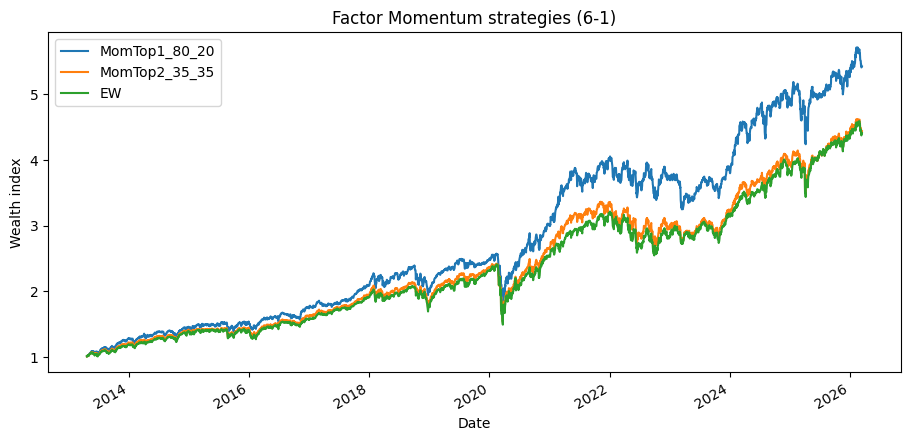

In [15]:

wealth = wealth_index(rets)
ax = wealth.plot(figsize=(11, 5), title=f"Factor Momentum strategies ({VARIANT})")
ax.set_ylabel("Wealth index")
plt.show()



## Optional data-driven block-length selection

A simple heuristic is provided to choose the average block length by matching the autocorrelation function of **absolute returns** for the main strategy. For this project, using `MomTop1_80_20` as the reference strategy is usually sensible.


In [17]:

if RUN_ACF_BLOCK_SELECTION:
    bl = choose_block_length_by_acf_matching(
        rets["MomTop1_80_20"],
        candidates=ACF_CANDIDATES,
        nlags=ACF_NLAGS,
        n_boot=ACF_N_BOOT,
        use_abs=True,
        seed=BOOTSTRAP_SEED,
        distance="weighted",
    )
    best_L = bl["best_L"]
    print("Suggested avg_block_len:", best_L)
    display(bl["scores"])
else:
    best_L = AVG_BLOCK_LEN
    print("Using fixed avg_block_len:", best_L)


Suggested avg_block_len: 30


,0
5,0.073015
10,0.048524
20,0.033927
30,0.029428



## Politis–Romano stationary bootstrap

The stationary bootstrap is applied to the **panel of factor-ETF returns**, and the entire strategy is rebuilt inside each bootstrap sample. This is preferable to bootstrapping the final strategy return series directly because it preserves the **signal-construction / portfolio-construction loop**.


In [18]:

if RUN_BOOTSTRAP:
    boot = bootstrap_factor_mom_metrics(
        r,
        variant=VARIANT,
        n_boot=N_BOOT,
        avg_block_len=best_L,
        seed=BOOTSTRAP_SEED,
    )

    boot_actual_metrics = boot["actual_metrics"]
    boot_cagr = boot["bootstrap_tables"]["CAGR"]
    boot_shr = boot["bootstrap_tables"]["ShR"]
    boot_martin = boot["bootstrap_tables"]["Martin"]
    boot_mxdd = boot["bootstrap_tables"]["MxDD"]

    print("Actual backtest metrics:")
    display(boot_actual_metrics.round(4))

    print("Bootstrap distribution — CAGR")
    display(boot_cagr.round(4))

    print("Bootstrap distribution — Sharpe ratio")
    display(boot_shr.round(4))

    print("Bootstrap distribution — Martin ratio")
    display(boot_martin.round(4))

    print("Bootstrap distribution — Max drawdown")
    display(boot_mxdd.round(4))


Actual backtest metrics:


,n,CAGR,AnnVol,MxDD,ShR,SoR,Calmar,Ulcer,Martin
MomTop1_80_20,3246.0,0.1403,0.1747,-0.3318,0.8392,1.3249,0.4228,0.0573,2.4478
MomTop2_35_35,3246.0,0.1226,0.1629,-0.3681,0.7920,1.2232,0.3332,0.0617,1.9888
EW,3246.0,0.1221,0.1624,-0.3808,0.7908,1.2132,0.3206,0.0612,1.9957


Bootstrap distribution — CAGR


,mean,p05,p50,p95,n
Strategy,,,,,
MomTop1_80_20,0.1242,0.0437,0.1247,0.2014,1000.0
MomTop2_35_35,0.1244,0.0486,0.1247,0.1994,1000.0
EW,0.1224,0.0524,0.1235,0.1919,1000.0


Bootstrap distribution — Sharpe ratio


,mean,p05,p50,p95,n
Strategy,,,,,
MomTop1_80_20,0.7730,0.3161,0.7658,1.2378,1000.0
MomTop2_35_35,0.8103,0.3636,0.8023,1.2933,1000.0
EW,0.8191,0.3775,0.8040,1.3130,1000.0


Bootstrap distribution — Martin ratio


,mean,p05,p50,p95,n
Strategy,,,,,
MomTop1_80_20,1.6101,0.2144,1.3583,3.8343,1000.0
MomTop2_35_35,1.7970,0.2937,1.5082,4.3716,1000.0
EW,1.8534,0.3218,1.5578,4.5419,1000.0


Bootstrap distribution — Max drawdown


,mean,p05,p50,p95,n
Strategy,,,,,
MomTop1_80_20,-0.3462,-0.5324,-0.3396,-0.1795,1000.0
MomTop2_35_35,-0.3315,-0.5068,-0.3431,-0.1741,1000.0
EW,-0.3231,-0.4923,-0.3343,-0.1657,1000.0



## Latest results snapshot used for CV / GitHub

The tables below reproduce the latest reported results supplied for this project. They are included here so that the notebook remains informative even when the data source is not executed live.


In [19]:

latest_actual_metrics = pd.DataFrame(
    {
        "n": [3246.0, 3246.0, 3246.0],
        "CAGR": [0.1403, 0.1227, 0.1220],
        "AnnVol": [0.1747, 0.1629, 0.1624],
        "MxDD": [-0.3318, -0.3681, -0.3808],
        "ShR": [0.8394, 0.7920, 0.7907],
        "SoR": [1.3252, 1.2233, 1.2130],
        "Calmar": [0.4229, 0.3332, 0.3205],
        "Ulcer": [0.0573, 0.0617, 0.0612],
        "Martin": [2.4485, 1.9889, 1.9953],
    },
    index=["MomTop1_80_20", "MomTop2_35_35", "EW"],
)

display(latest_actual_metrics.round(4))

latest_boot_cagr = pd.DataFrame(
    {
        "mean": [0.1242, 0.1244, 0.1224],
        "p05": [0.0437, 0.0486, 0.0523],
        "p50": [0.1248, 0.1247, 0.1235],
        "p95": [0.2015, 0.1994, 0.1918],
        "n": [1000.0, 1000.0, 1000.0],
    },
    index=["MomTop1_80_20", "MomTop2_35_35", "EW"],
)

latest_boot_shr = pd.DataFrame(
    {
        "mean": [0.7729, 0.8101, 0.8189],
        "p05": [0.3163, 0.3636, 0.3774],
        "p50": [0.7659, 0.8023, 0.8040],
        "p95": [1.2378, 1.2933, 1.3128],
        "n": [1000.0, 1000.0, 1000.0],
    },
    index=["MomTop1_80_20", "MomTop2_35_35", "EW"],
)

latest_boot_martin = pd.DataFrame(
    {
        "mean": [1.6096, 1.7964, 1.8528],
        "p05": [0.2147, 0.2934, 0.3217],
        "p50": [1.3577, 1.5077, 1.5575],
        "p95": [3.8341, 4.3715, 4.5414],
        "n": [1000.0, 1000.0, 1000.0],
    },
    index=["MomTop1_80_20", "MomTop2_35_35", "EW"],
)

latest_boot_mxdd = pd.DataFrame(
    {
        "mean": [-0.3462, -0.3316, -0.3231],
        "p05": [-0.5324, -0.5068, -0.4923],
        "p50": [-0.3396, -0.3431, -0.3343],
        "p95": [-0.1795, -0.1741, -0.1657],
        "n": [1000.0, 1000.0, 1000.0],
    },
    index=["MomTop1_80_20", "MomTop2_35_35", "EW"],
)

print("Latest stationary-bootstrap summary — CAGR")
display(latest_boot_cagr.round(4))

print("Latest stationary-bootstrap summary — Sharpe ratio")
display(latest_boot_shr.round(4))

print("Latest stationary-bootstrap summary — Martin ratio")
display(latest_boot_martin.round(4))

print("Latest stationary-bootstrap summary — Max drawdown")
display(latest_boot_mxdd.round(4))


,n,CAGR,AnnVol,MxDD,ShR,SoR,Calmar,Ulcer,Martin
MomTop1_80_20,3246.0,0.1403,0.1747,-0.3318,0.8394,1.3252,0.4229,0.0573,2.4485
MomTop2_35_35,3246.0,0.1227,0.1629,-0.3681,0.7920,1.2233,0.3332,0.0617,1.9889
EW,3246.0,0.1220,0.1624,-0.3808,0.7907,1.2130,0.3205,0.0612,1.9953


Latest stationary-bootstrap summary — CAGR


,mean,p05,p50,p95,n
MomTop1_80_20,0.1242,0.0437,0.1248,0.2015,1000.0
MomTop2_35_35,0.1244,0.0486,0.1247,0.1994,1000.0
EW,0.1224,0.0523,0.1235,0.1918,1000.0


Latest stationary-bootstrap summary — Sharpe ratio


,mean,p05,p50,p95,n
MomTop1_80_20,0.7729,0.3163,0.7659,1.2378,1000.0
MomTop2_35_35,0.8101,0.3636,0.8023,1.2933,1000.0
EW,0.8189,0.3774,0.8040,1.3128,1000.0


Latest stationary-bootstrap summary — Martin ratio


,mean,p05,p50,p95,n
MomTop1_80_20,1.6096,0.2147,1.3577,3.8341,1000.0
MomTop2_35_35,1.7964,0.2934,1.5077,4.3715,1000.0
EW,1.8528,0.3217,1.5575,4.5414,1000.0


Latest stationary-bootstrap summary — Max drawdown


,mean,p05,p50,p95,n
MomTop1_80_20,-0.3462,-0.5324,-0.3396,-0.1795,1000.0
MomTop2_35_35,-0.3316,-0.5068,-0.3431,-0.1741,1000.0
EW,-0.3231,-0.4923,-0.3343,-0.1657,1000.0
